[![Apri in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/riccardoberta/regressione/blob/main/04_generalizzazione_overfitting.ipynb)

# Generalizziamo a giocatori nuovi!

Un modello può sembrare molto preciso sui dati che ha già "visto" (che hanno fatto parte dei dati utilizzati per il suo addestramento). Ma il vero obiettivo del machine learning non è "**memorizzare**" quei dati, bensì prevedere bene su giocatori nuovi. Questa operazione si chiama **generalizzazione**: un modello generalizza bene quando riesce a fare previsioni accurate su dati che non ha mai visto prima. È come dare a uno studente un compito identico a quello di ripasso, e poi dichiararlo bravissimo perché ha preso dieci. **Ma se gli proponessimo un esercizio mai visto?** Per questo motivo è fondamentale dividere i dati a nostra disposizione in due gruppi:

- alcuni dati che usiamo per allenare il modello (**training set**)
- alcuni dati che usiamo per valutarlo (**test set**)

Separare i dati in allenamento e test, ci aiuta a capire se un modello sta **imparando una regola** oppure se sta **memorizzando i dati**. Apriamo per l'ultima volta il dataset: stavolta non aggiungeremo features, ma cambieremo radicalmente il modo in cui giudichiamo i modelli.

In [52]:
# Librerie necessarie per scaricare ed estrarre il dataset
import urllib.request, zipfile
from pathlib import Path

# Librerie per l'analisi dei dati e la visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Link al dataset e percorsi locali
DATA_URL = (
    "https://www.dropbox.com/scl/fi/0l5n46qjwcd5moj3w7d8p/"
    "fifa.zip?rlkey=rcqhagvq5ttlvna5t5r3vn1bm&st=uzplzs5o&dl=1"
)
ZIP_PATH = Path("fifa.zip")
DATA_DIR = Path("fifa_data")

# Scarichiamo il dataset se non è già presente
if not ZIP_PATH.exists():
    print("Scarico il dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

# Estraiamo il dataset se non è già stato fatto
if not list(DATA_DIR.rglob("*.csv")):
    DATA_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)

# Cerchiamo il file CSV dei giocatori dentro la cartella estratta
csv_files = (
    list(DATA_DIR.rglob("players_22.csv"))
    or list(DATA_DIR.rglob("*players*.csv"))
)

# Carichiamo il CSV in un DataFrame pandas: ogni riga = un giocatore
raw_data = pd.read_csv(csv_files[0], low_memory=False)

# Definiamo un sottoinsieme di colonne che ci interessano
wanted_columns = [
    "short_name", "age", "overall", "potential", "wage_eur", "value_eur",
    "club_name", "league_name", "player_positions"
]

# Prendiamo solo le colonne che ci interessano e copiamo il dataset
# per lavorarci sopra senza modificare l'originale
dataset = raw_data[wanted_columns].copy()

# Manteniamo solo i giocatori con valore noto e positivo
dataset = dataset.dropna(subset=["value_eur", "age", "overall", "potential"])
dataset = dataset[dataset["value_eur"] > 0]

# Riduciamo l'effetto dei super-giocatori (l'1% più costoso)
dataset = dataset[dataset["value_eur"] <= dataset["value_eur"].quantile(0.99)]

# Per leggibilità usiamo il valore in milioni di euro
dataset["value_mln_eur"] = dataset["value_eur"] / 1_000_000
if "wage_eur" in dataset.columns:
    dataset["wage_k_eur"] = dataset["wage_eur"] / 1_000

# Aggiungiamo un po' di rumore ai valori per rendere il problema più realistico
# Costruiamo un generatore di numeri casuali
rng = np.random.default_rng(42)
dataset["value_mln_eur"] = (dataset["value_mln_eur"] + rng.normal(0, 1.0, len(dataset))).clip(lower=0.05)


## Valutiamo la generalizzazione

Per valutare la generalizzazione di un modello, dobbiamo prima dividere i dati in due gruppi: uno per l'allenamento e uno per il test. Scikit-learn ci offre una funzione molto comoda per fare questo, chiamata **train_test_split**. La useremo per dividere i nostri dati in modo casuale, mantenendo però una parte dei dati completamente separata per la valutazione finale. Poi cerchremo di capire come misurare la qualità delle previsioni sui dati di test e come interpretare i risultati.

### training e test set

Mettiamo da parte una porzione dei dati (ad esempio il 25% dei giocatori) e la usiamo come test set: un insieme di esempi nuovi, che il modello **non vedrà mai durante l’addestramento**. Il resto dei dati costituisce il training set, su cui il modello impara. L’idea è molto intuitiva: alleniamo lo scout su alcuni giocatori e poi gli chiediamo di valutare calciatori che non ha mai visto prima. Se il modello funziona bene anche su questi nuovi casi, significa che ha imparato qualcosa di generale. Se invece le prestazioni peggiorano molto, vuol dire che si era adattato troppo ai dati di partenza.

In [53]:
# Importiamo la funzione per dividere i dati in training e test set
from sklearn.model_selection import train_test_split

# Scegliamo le features che vogliamo usare per il modello più ricco
features = ["age", "overall", "potential", "wage_eur"]
x = dataset[features]
y = dataset["value_mln_eur"]

# train_test_split divide casualmente i dati in due parti:
# - 75% per addestrare (training set)
# - 25% per valutare il modello su dati che non ha mai visto (test set)
# random_state=42 garantisce che la divisione sia riproducibile.
x_train, x_test, y_train, y_test = train_test_split(x, y,            
                                                    test_size=0.25, 
                                                    random_state=12)

print("Esempi di training:", len(x_train))
print("Esempi di test:", len(x_test))

Esempi di training: 14229
Esempi di test: 4744


E' molto importante che il test set sia **completamente separato dal training set**, e che non venga mai usato per nessuna ragione durante le fasi di creazione del modello. Se il modello "vede" i dati di test, anche indirettamente attraverso la scelta delle features o la definizione di alcuni parametri, come la learning rate, rischiamo di ottenere un modello che in qualche modo "sfrutta" le informazioni contenute nel test set, e quindi la valutazione del modello sul test set non sarà più attendibile come misura delle sue prestazioni su dati sconosciuti. Ma come facciamo queste misure?

### Errore di training vs errore atteso

Quello che vorremmo davvero misurare è quanto sbaglierà il modello sui casi futuri, i giocatori che il direttore sportivo dovrà valutare la prossima estate. In termini matematici, questo corrisponde al cosiddetto **errore atteso**:

$\displaystyle R(f) = \mathbb{E}_{(x, y)}\!\left[(y - f(x))^2\right]$

cioè la **media dell’errore su tutti i possibili giocatori, presenti e futuri**. Naturalmente, questo valore non è calcolabile esattamente: non conosciamo tutti i dati possibili del mondo. Quello che possiamo calcolare è **l’errore empirico sui dati che abbiamo a disposizione**, ad esempio sul training set:

$\displaystyle \hat{R}_{\text{train}}(f) = \frac{1}{n_{\text{train}}} \sum_{i \in \text{train}} (y_i - f(x_i))^2$

Questo numero ci dice quanto bene il modello si adatta ai dati su cui è stato addestrato. Ma qui sta il punto delicato: questo valore può essere **fuorviante**. Un modello molto flessibile può rendere l’errore di training estremamente piccolo, anche vicino a zero, semplicemente "imparando a memoria" i dati, senza aver davvero capito la relazione tra le variabili. Per ottenere una stima più onesta dell’errore atteso, dobbiamo **misurare l’errore su dati che il modello non ha mai visto** durante l’addestramento, cioè sul test set:

$\displaystyle \hat{R}_{\text{test}}(f) = \frac{1}{n_{\text{test}}} \sum_{i \in \text{test}} (y_i - f(x_i))^2$

Questo è il numero che conta davvero: se è basso, significa che il modello è in grado di generalizzare; se è alto, vuol dire che il modello ha imparato troppo bene i dati di partenza ma non riesce a funzionare su casi nuovi. In sintesi, non basta che un modello funzioni bene sul passato: deve essere in grado di prevedere il futuro.

## Rivalutiamo i nostri modelli

Rivisitiamo tutti i nostri modelli, quello lineare semplice, quello multivariato, quello polinomiale e quello ad albero di decisione, ma questa volta li addestriamo solo sui dati di training e poi li valutiamo sui dati di test. Vediamo come cambia la nostra percezione della loro qualità, e se i modelli più complessi riescono davvero a funzionare meglio di quelli più semplici.

In [54]:
# === Modello 1: lineare semplice (solo overall)

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error

x_train_one = x_train[["overall"]]
x_test_one  = x_test[["overall"]]

model_single = SGDRegressor(loss="squared_error",
                            max_iter=1000,
                            eta0=0.01,
                            random_state=12)
model_single.fit(x_train_one, y_train)

mae_single_train = mean_absolute_error(y_train, model_single.predict(x_train_one))
mae_single_test  = mean_absolute_error(y_test,  model_single.predict(x_test_one))

In [55]:
# === Modello 2: lineare multivariato (4 feature, normalizzate)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

model_many = make_pipeline(MinMaxScaler(),
                           SGDRegressor(loss="squared_error",
                                        max_iter=1000,
                                        eta0=0.01,
                                        random_state=12))

model_many.fit(x_train, y_train)

mae_many_train = mean_absolute_error(y_train, model_many.predict(x_train))
mae_many_test  = mean_absolute_error(y_test,  model_many.predict(x_test))

In [56]:
# === Modello 3: polinomiale

from sklearn.preprocessing import PolynomialFeatures

model_poly = make_pipeline(PolynomialFeatures(degree=5, include_bias=False),
                           MinMaxScaler(),
                           SGDRegressor(loss="squared_error",
                                        max_iter=1000,
                                        eta0=0.01,
                                        random_state=12))

model_poly.fit(x_train, y_train)

mae_poly_train = mean_absolute_error(y_train, model_poly.predict(x_train))
mae_poly_test  = mean_absolute_error(y_test,  model_poly.predict(x_test))

In [57]:
# === Modello 4: albero di decisione

from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=12)
tree_model.fit(x_train, y_train)

mae_tree_train = mean_absolute_error(y_train, tree_model.predict(x_train))
mae_tree_test  = mean_absolute_error(y_test,  tree_model.predict(x_test))

### Overfitting

Ora che abbiamo addestrato tutti i modelli e calcolato l’errore sia sul training set che sul test set, possiamo confrontare i risultati. Affianchiamo in una tabella il MAE di training e il MAE di test per ciascun modello. Questo confronto è molto più informativo del singolo numero, perché ci permette di capire non solo quanto il modello è preciso, ma anche come si comporta fuori dai dati che ha visto. Il punto chiave è il **divario** tra le due colonne: se l’errore "in casa" (training) è molto più basso dell’errore "in trasferta" (test), significa che il modello si è adattato troppo ai dati di partenza, senza imparare una regola generale. Al contrario, quando i due valori sono simili: il modello sta generalizzando bene, cioè riesce a mantenere prestazioni simili anche su dati nuovi.

In [58]:
# Predisponiamo la tabella di confronto
risultati = pd.DataFrame({
    "modello": [
        "Lineare semplice",
        "Lineare multivariato",
        "Polinomiale",
        "Albero di decisione",
    ],
    "MAE training (mln €)": [
        mae_single_train, mae_many_train, mae_poly_train, mae_tree_train,
    ],
    "MAE test (mln €)": [
        mae_single_test, mae_many_test, mae_poly_test, mae_tree_test,
    ],
})

# Aggiungiamo una colonna che evidenzia il divario tra training e test
risultati["divario"] = risultati["MAE test (mln €)"] - risultati["MAE training (mln €)"]

# Mostriamo la tabella con i risultati arrotondati a 3 decimali
risultati.round(3)

,modello,MAE training (mln €),MAE test (mln €),divario
0,Lineare semplice,3.447,3.482,0.035
1,Lineare multivariato,1.589,1.586,-0.002
2,Polinomiale,1.096,1.070,-0.026
3,Albero di decisione,0.292,0.951,0.659


I primi tre modelli (lineare semplice, lineare multivariato e polinomiale) mostrano un comportamento molto rassicurante: l'errore in casa e l'errore in trasferta sono simili, con un divario relativamente basso. Questo significa che ciò che hanno imparato sui dati di training funziona altrettanto bene su giocatori che non avevano mai visto. In altre parole, **stanno generalizzando bene**: hanno catturato una regola, non memorizzato esempi. L'osservazione che a volte l'errore di test sia leggermente più piccolo di quello di training non deve sorprendere e non significa nulla di magico. È semplicemente **rumore statistico**: con la divisione casuale, il test set può capitare un po' più "facile" del training. È tipico, e si verifica spesso quando il modello generalizza bene.

L'albero di decisione, invece, dipinge un quadro completamente diverso. Nel notebook precedente eravamo rimasti a bocca aperta davanti a un MAE molto basso. Ora, valutato in modo onesto, il MAE di test sale parecchio. Il divario tra training e test è la firma inconfondibile del fenomeno chiamato **overfitting**: l'albero ha imparato i singoli giocatori del training a memoria, e quando incontra qualcuno di nuovo paga il conto.

### Facciamo meglio!

Il risultato è in linea con quello che ci aspettavamo. L’albero era estremamente preciso sul training set, quasi come un oracolo, ma questa precisione era in gran parte illusoria: il modello aveva imparato anche il rumore dei dati, perdendo capacità di generalizzazione. Sul test set, infatti, le prestazioni peggiorano sensibilmente.

Possiamo fare qualcosa per migliorare la situazione? Sì. Il problema principale è **l’eccessiva flessibilità del modello**: un albero di decisione può costruire regole molto complesse, adattandosi perfettamente a ogni dettaglio del training set, ma proprio per questo rischia di non funzionare bene su dati nuovi.

Per rendere il modello più robusto, dobbiamo **limitare questa flessibilità**. In generale, questo significa costringere il modello a imparare regole più semplici, che non inseguano ogni singolo caso del training, ma che catturino solo le tendenze più importanti. Questa idea prende il nome di **regolarizzazione**.

Nel caso degli alberi di decisione, un modo semplice per regolarizzare è **limitare la profondità massima**. In questo modo impediamo al modello di creare troppe suddivisioni e lo forziamo a costruire una struttura più compatta e generale. Se limitiamo la profondità, cosa ci aspettiamo?

In [59]:
from sklearn.tree import DecisionTreeRegressor

tree_model_regularized = DecisionTreeRegressor(max_depth=2, random_state=12)
tree_model_regularized.fit(x_train, y_train)

mae_tree_regularized_train = mean_absolute_error(y_train, tree_model_regularized.predict(x_train))
mae_tree_regularized_test = mean_absolute_error(y_test, tree_model_regularized.predict(x_test))

print(f"MAE albero regolarizzato (train): {mae_tree_regularized_train:.3f} mln €")
print(f"MAE albero regolarizzato (test): {mae_tree_regularized_test:.3f} mln €")

print(f"MAE albero libero (train): {mae_tree_train:.3f} mln €")
print(f"MAE albero libero (test): {mae_tree_test:.3f} mln €")


MAE albero regolarizzato (train): 1.246 mln €
MAE albero regolarizzato (test): 1.268 mln €
MAE albero libero (train): 0.292 mln €
MAE albero libero (test): 0.951 mln €


### Underfitting

Il modello regolarizzato non è più perfetto "in casa", ma è molto più coerente tra training e test. In altre parole, ha smesso di inseguire i dettagli dei dati e ha imparato una regola più generale. C’è però un aspetto interessante, l’errore di test dell’albero libero è più basso di quello regolarizzato. Questo è un problema inverso che si chiama **underfitting**: il modello regolarizzato è forse troppo semplice, e non riesce a catturare tutte le sfumature dei dati, perdendo precisione anche su casi nuovi. Abbiamo dunque un bel **problema di bilanciamento** (trade-off) tra due estremi:

- modelli troppo flessibili tendono all'overfitting (come l'albero libero) e non generalizzano bene
- modelli troppo semplici tendono all'underfitting (come l'albero regolarizzato o anche i modelli lineari) e non riescono a catturare le relazioni nei dati

Spesso nel machine learning il nostro obiettivo è trovare il **giusto equilibrio** tra i due.

### La curva a U dell'overfitting

Quanto abbiamo visto finora (albero libero brillante in casa ma debole in trasferta, albero potato un po' meno brillante ma più affidabile) è un caso particolare di un fenomeno generale. Possiamo provare a tracciare un grafico dell'errore di test in funzione della complessità del modello, ad esempio variando la profondità massima dell'albero. In questo grafico, vedremo una curva a U: all'inizio, quando il modello è troppo semplice, l'errore è alto (underfitting).

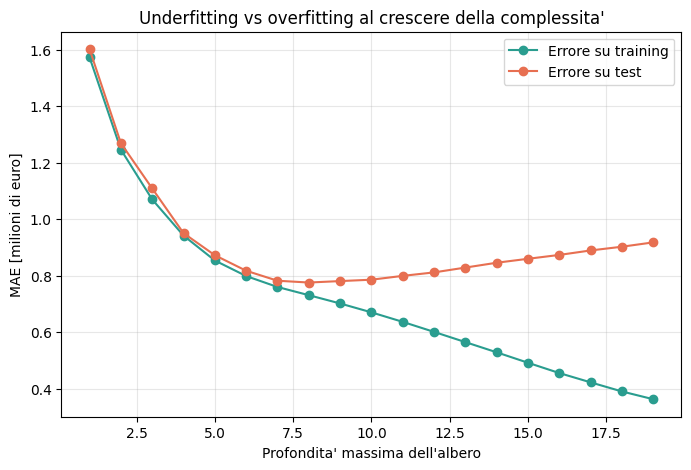

In [60]:
# Profondità da 1 a 20: una lista di valori da provare
profondita = list(range(1, 20))
err_train = []
err_test = []

# Per ogni profondità: costruiamo l'albero, lo addestriamo, misuriamo
# l'errore sui due insiemi e salviamo i risultati nelle due liste.
for d in profondita:
    m = DecisionTreeRegressor(max_depth=d, random_state=12)
    m.fit(x_train, y_train)
    err_train.append(mean_absolute_error(y_train, m.predict(x_train)))
    err_test.append(mean_absolute_error(y_test, m.predict(x_test)))

# Disegniamo le due curve sullo stesso grafico per confrontarle
plt.figure(figsize=(8,5))
plt.plot(profondita, err_train, "o-", label="Errore su training", color="#2a9d8f")
plt.plot(profondita, err_test, "o-", label="Errore su test", color="#e76f51")

plt.xlabel("Profondita' massima dell'albero")
plt.ylabel("MAE [milioni di euro]")
plt.title("Underfitting vs overfitting al crescere della complessita'")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Il grafico mostra il fenomeno di cui abbiamo parlato a parole: una curva a U che racconta tutta la vita di un modello al crescere della sua complessità. 

**Il ramo sinistro è la parte di underfitting**. Per profondità basse sia l'errore di training sia quello di test sono alti. L'albero è così rigido da non riuscire a catturare nemmeno la struttura vera dei dati: a un giocatore con overall basso e a uno con overall altissimo assegna previsioni troppo simili, perché ha poche foglie a disposizione. È il classico **modello troppo semplice**: sbaglia in casa quanto in trasferta perché non sta imparando abbastanza. In generale, tipologie di modello così semplice si dicono con **alti pregiudizi** (**bias**), perché hanno una struttura a priori che li limita molto, e non riescono a catturare le relazioni più complesse tra le variabili. Anche i modelli lineari, per esempio, sono modelli con alto bias: non riescono a catturare relazioni non lineari, e quindi spesso soffrono di underfitting.

**Il fondo della U è il punto giusto**. Verso profondità massime più alte le due curve raggiungono insieme il minimo. È il sweet spot: l'albero ha catturato i pattern principali (l'overall conta, lo stipendio conta, l'età ha un effetto non lineare) ma non si è ancora messo a inseguire i singoli giocatori del training. Le previsioni sono solide e l'errore di test è il più basso di tutta la curva.

**Il ramo destro è la parte di overfitting**. Con profondità troppo alte succede qualcosa di paradossale e illuminante: l'errore di training continua a scendere, l'albero diventa sempre più "bravo" sui giocatori che ha visto, ma l'errore di test comincia a risalire. Il modello sta usando la sua flessibilità non per imparare regole più raffinate, ma per memorizzare le particolarità dei singoli giocatori del training, particolarità che non si ripresentano nei giocatori del test. Più cresciamo in complessità, più il divario tra le due curve si allarga. La promessa del modello "più ricco è meglio" si rivela falsa. In generali, tipologie di modello così flessibili si dicono con **alta varianza**: piccoli cambiamenti nei dati di training possono portare a grandi cambiamenti nelle previsioni, perché il modello si adatta troppo ai dettagli dei dati di partenza. Anche le reti neurali molto profonde, se non regolarizzate, possono soffrire di overfitting proprio per questo motivo.

possiamo concludere che esiste **una complessità ottimale per ogni problema**. Sotto quel livello soffriamo di bias (il modello è troppo rigido e perde struttura reale), sopra di varianza (il modello è troppo flessibile e insegue il rumore). Il punto migliore non è la massima flessibilità possibile, ma **il punto in cui le due forze si bilanciano**. Trovarlo è uno dei mestieri principali del machine learning, e si fa esattamente come abbiamo appena fatto: provando diversi livelli di complessità, misurando con un test set onesto, e scegliendo quello che minimizza l'errore fuori dai dati visti.

Troviamo allora questa profondità ottimale per il nostro scout automatico.

In [61]:
best_idx = int(np.argmin(err_test))
best_d   = profondita[best_idx]
print(f"Profondità con errore di test minimo: {best_d}")

Profondità con errore di test minimo: 8


Il numero che abbiamo trovato come ottimale non sarebbe mai emerso senza il test set. Senza la divisione train/test, avremmo visto solo la curva dell'errore di training (che scende sempre), che ci avrebbe convinti che "più profondo è sempre meglio". Il test set è ciò che ci salva da questo errore: ci mostra che dopo un certo punto la flessibilità non è più una virtù, ma una trappola.

### Facciamo scouting, fatto bene!

Ora che abbiamo scelto una profondità che rappresenta un buon compromesso, possiamo fare un passo importante. Finora abbiamo usato il training set per provare diverse configurazioni del modello e capire quale funziona meglio. Una volta presa questa decisione, non dobbiamo più cambiare il modello: possiamo considerarla una **scelta definitiva**. A questo punto, però, abbiamo ancora un problema: abbiamo usato solo una parte dei dati per addestrare il modello (quella che abbiamo chiamato training set), e quindi non stiamo sfruttando tutte le informazioni a nostra disposizione. Prima di consegnare il nostro scout al direttore sportivo, vogliamo dargli il meglio possibile, e per farlo dobbiamo addestrarlo su tutti i dati che abbiamo, compresi quelli che avevamo messo da parte per il training. Purtroppo però così facendo, rischiamo di perdere la stima onesta dell'errore atteso che avevamo ottenuto con il test set. Come possiamo risolvere questo dilemma? 

La soluzione che avremmo dovuto adottare fin dall'inizio, è quella di dividere i dati in tre gruppi invece che due:

- **training set**: usato per addestrare il modello e provare diverse configurazioni
- **validation set**: usato per scegliere la configurazione finale del modello (ad esempio la profondità ottimale)
- **test set**: usato solo alla fine, per valutare le prestazioni del modello scelto su dati completamente nuovi

Il modello finale lo addestriamo sui dati di training e di validation, e lo valuteremo solo alla fine sul test set, per avere una stima onesta delle sue prestazioni su dati sconosciuti da fornire, assieme al modello, al direttore sportivo. Il test set deve essere piccolo, perchè non lo potremo sfruttare per addestrare il modello, ma è fondamentale che sia abbastanza grande da garantire una valutazione affidabile, e che sia completamente separato da tutte le fasi di costruzione del modello, per garantire una valutazione onesta. In questo modo, sfruttiamo al massimo le informazioni a nostra disposizione senza compromettere la valutazione finale.

Per non complicare ulteriormente questo notebook, restiamo alla divisione in due, predisponiamo il modello addestrato sul training set usando il miglior valore di profondità che abbiamo trovato, e come stima onesta dell'errore atteso usiamo il test set e consegniamo al direttore sportivo uno scout che sappiamo essere affidabile su giocatori nuovi.

In [62]:
best_model = DecisionTreeRegressor(max_depth=best_d, random_state=12)
best_model.fit(x_train, y_train)

mae_best_train = mean_absolute_error(y_train, best_model.predict(x_train))
mae_best_test  = mean_absolute_error(y_test,  best_model.predict(x_test))

print(f"MAE modello ottimale (train): {mae_best_train:.3f} mln €")
print(f"MAE modello ottimale (test): {mae_best_test:.3f} mln €")

MAE modello ottimale (train): 0.731 mln €
MAE modello ottimale (test): 0.776 mln €


Prima di consegnare il modello, però, vogliamo vedere con i nostri occhi come si comporta su giocatori che non ha mai visto prima. Come al solito. estraiamo a caso 10 giocatori dal test set, e usiamo il nostro modello per fare le previsioni sul loro valore. Poi confrontiamo queste previsioni con i valori reali, per vedere se lo scout è davvero in grado di valutare calciatori nuovi.

In [63]:
# Estraiamo 10 giocatori a caso tra quelli del test set, che il modello non ha mai visto durante l'addestramento.
sample_idx = x_test.sample(10, random_state=7).index
sample = x_test.loc[sample_idx].copy()

# Aggiungiamo i nomi dei giocatori, che servono per leggere la tabella.
# Li recuperiamo dal dataset originale usando l'indice del test set.
sample["short_name"] = dataset.loc[sample_idx, "short_name"]

# Aggiungiamo il valore reale (preso da y_test, non da X_test)
sample["valore_reale"] = y_test.loc[sample_idx]

# Chiediamo allo scout la sua previsione per ognuno dei 10 giocatori
sample["previsione"] = best_model.predict(x_test.loc[sample_idx])

# Calcoliamo l'errore: previsione - valore reale
# (positivo = sovrastima, negativo = sottostima)
sample["errore"] = sample["previsione"] - sample["valore_reale"]

# Mostriamo la tabella riordinata, con le colonne che contano
sample[[
    "short_name", "age", "overall", "potential", "wage_eur",
    "valore_reale", "previsione", "errore",
]].round(2)

,short_name,age,overall,potential,wage_eur,valore_reale,previsione,errore
10264,S. McMann,24,65,69,2000.0,0.75,0.84,0.09
4322,C. De Norre,24,71,76,8000.0,2.25,2.60,0.35
4898,M. Mier,30,70,70,8000.0,2.30,1.35,-0.94
1518,R. Alessandrini,32,75,75,16000.0,6.44,3.78,-2.66
15799,S. Araujo,24,60,68,500.0,0.05,0.66,0.61
8544,T. Břečka,27,67,68,5000.0,1.57,1.21,-0.36
2534,J. Aquino,31,73,73,34000.0,0.28,2.55,2.27
12453,M. Lauritsen,28,63,63,2000.0,0.21,0.63,0.43
15709,M. Majouga,20,60,72,850.0,2.08,0.76,-1.32
12911,J. Reyes,23,63,70,9000.0,0.61,1.01,0.39


Lo scout non è perfetto, ma è onesto. Sui giocatori "tipici" del nostro dataset sbaglia di poche centinaia di migliaia di euro; sui casi più rari (stipendi anomali rispetto all'overall, età estreme) l'errore può salire a uno o due milioni. È esattamente quello che ci aspettiamo da un modello che ha imparato regole generali invece di memorizzare singoli casi: funziona benissimo dove c'è abbondanza di esempi simili e fatica dove i giocatori si comportano "fuori dagli schemi"

Infine, salviamo su file i modelli che abbiamo appena costruito in modo da non doverli riaddestrare dopo tutta la fatica che abbiamo fatto. Queste saranno le informazioni che consegneremo al direttore sportivo, assieme alle informazioni sugli errori di training e test. Per salvare i modelli, useremo **joblib**, lo strumento standard di scikit-learn per serializzare modelli addestrati: produce un singolo file binario che possiamo ricaricare in qualsiasi altro notebook esattamente come l'avevamo lasciato.

In [64]:
# Includiamo joblib, la libreria standard per salvare modelli scikit-learn.
import joblib

# Raccogliamo i quattro modelli addestrati e la lista delle
# feature usate (ci serve per ricostruire X nello stesso ordine).
modelli_addestrati = {
    "lineare_semplice": model_single,
    "lineare_ricco":    model_many,
    "polinomiale":      model_poly,
    "albero":           best_model,
    "features":         features,
}

# Salviamo su file
joblib.dump(modelli_addestrati, "modelli_scout.joblib")

print("Modelli salvati in 'modelli_scout.joblib'")

Modelli salvati in 'modelli_scout.joblib'


> **Cosa dovremmo aver capito** — Siamo partiti da una tabella di calciatori e siamo arrivati a costruire e valutare modelli predittivi onesti. Lungo il cammino abbiamo incontrato i tre mattoni di ogni algoritmo di machine learning (una formula con dei parametri, una funzione costo che ne misura gli errori, un algoritmo di apprendimento che cerca i parametri migliori) e li abbiamo visti diventare via via più sofisticati: dalla retta a un solo indizio, alla retta a più indizi, ai polinomi, agli alberi di decisione. In quest'ultima tappa abbiamo aggiunto l'ingrediente più importante di tutti: la valutazione onesta. Un modello non si giudica dai dati che ha già visto, ma da quelli che incontrerà in futuro. Da questa idea nascono le distinzioni di oggi (training vs test, underfitting vs overfitting, bias vs varianza) e nasce la consapevolezza che la massima flessibilità non è quasi mai la miglior scelta. Esiste, per ogni problema, una complessità giusta: trovarla è il lavoro vero del data scientist. Anche se oggi alcuni risultati di modelli con miliardi di parametri (quelli alla base di chatbot come ChatGPT) sembrano smentire questa regola, in realtà non è così: questi modelli "iper-parametrizzati" riescono a regolarizzarsi in modi molto sofisticati, che neppure i ricercatori del settore hanno ancora compreso del tutto. Ma questo è un argomento per il futuro!